# Multimodal LLM, VLLM으로 Chart와 Table 생성  

1. 차트 생성을 위한 python 코드로 chart 생성 후 img로 저장    
2. Markdown 생성  


In [ ]:
import os
from dotenv import load_dotenv
import textwrap
from IPython.display import display
from IPython.display import Markdown
import time
from pprint import pprint


# Load environment variables from .env file
load_dotenv()

# Get the environment variable


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))


In [5]:
import openai

# OpenAI API Key
OPEN_API_KEY = os.getenv("OPEN_API_KEY")

# Open AI API Key setting

openai.api_key = OPEN_API_KEY

In [6]:
from google import genai

# Gemini API Key  
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_CONFIG_PATH= os.getenv("GEMINI_CONFIG_PATH")

# Used to securely store your API key
#from google.colab import userdata
# Or use `os.getenv('GOOGLE_API_KEY')` to fetch an environment variable.
#GOOGLE_API_KEY=userdata.get(API_KEY)

#genai.configure(api_key=GEMINI_API_KEY)
'''
아래 코드는 Legacy 코드다. 
import google.generativeai as genai

# Gemini API Key  
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# Gemini API 키 설정
genai.configure(api_key=GEMINI_API_KEY)
'''

# Credentials 관련 조치
credentials_path = "gen-lang-client-0754073918-89536e9af6f4.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = credentials_path

## Table  

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate, ChatPromptTemplate 


# OpenAI LLM Wrappers (ChatGPT 또는 GPT-4 모델 사용)
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.4)

system_prompt = """You are a helpful assistant. You will produce a figure or table based on the user's request."""

# 프롬프트 작성
request = """
다음 데이터를 기반으로 테이블을 생성하세요:
- 열: 이름, 나이, 직업
- 데이터: 
  - Alice, 30, Engineer
  - Bob, 25, Designer
  - Charlie, 35, Teacher
"""


prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        ('human', '### User question ###: {request} ')
    ]
)



chain = prompt | llm

result = chain.invoke({"request": request})
result


AIMessage(content='| 이름    | 나이 | 직업      |\n|---------|-------|-----------|\n| Alice   | 30    | Engineer  |\n| Bob     | 25    | Designer  |\n| Charlie | 35    | Teacher   |', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 90, 'total_tokens': 141, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_79b79be41f', 'id': 'chatcmpl-BT619Ze9iCmTecxNHi47BEuTGLVCL', 'finish_reason': 'stop', 'logprobs': None}, id='run-5b7b6b3a-98ed-44e4-845b-aa1c54dff325-0', usage_metadata={'input_tokens': 90, 'output_tokens': 51, 'total_tokens': 141, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
result.content

'| 이름    | 나이 | 직업      |\n|---------|-------|-----------|\n| Alice   | 30    | Engineer  |\n| Bob     | 25    | Designer  |\n| Charlie | 35    | Teacher   |'

In [9]:
from pprint import pprint

pprint(result.content)

('| 이름    | 나이 | 직업      |\n'
 '|---------|-------|-----------|\n'
 '| Alice   | 30    | Engineer  |\n'
 '| Bob     | 25    | Designer  |\n'
 '| Charlie | 35    | Teacher   |')


In [3]:
table = '''('| 이름    | 나이 | 직업      |\n'
 '|---------|-------|-----------|\n'
 '| Alice   | 30    | Engineer  |\n'
 '| Bob     | 25    | Designer  |\n'
 '| Charlie | 35    | Teacher   |')'''

In [1]:
def extract_markdown_table(llm_response):
    """LLM 응답에서 Markdown 테이블 부분을 추출"""
    import re
    
    # 마크다운 테이블 패턴 찾기
    table_pattern = r'\|.*\|[\s\S]*?\|.*\|'
    table_match = re.search(table_pattern, llm_response)
    
    if table_match:
        return table_match.group(0)
    else:
        return None

In [2]:
def save_markdown_table(table_content, filename="table.md"):
    """추출한 테이블을 Markdown 파일로 저장"""
    if table_content:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(table_content)
        print(f"테이블이 {filename}에 저장되었습니다.")
    else:
        print("저장할 테이블이 없습니다.")

In [4]:
# 노트북의 기존 코드에서 LLM 응답 가져오기
llm_response = table

# 마크다운 테이블 추출
markdown_table = extract_markdown_table(llm_response)

# 파일로 저장
save_markdown_table(markdown_table, "generated_table.md")


테이블이 generated_table.md에 저장되었습니다.


In [6]:
def clean_table_string(table_str):
    """문자열 형태의 테이블을 정리"""
    # 따옴표와 괄호 제거
    clean_str = table_str.replace("'", "").replace("(", "").replace(")", "")
    
    # 줄바꿈 처리
    clean_str = clean_str.replace("\\n", "\n")
    
    return clean_str

# 예시: 노트북의 table 변수 정리하기
table_clean = clean_table_string(table)
with open("cleaned_table.md", "w", encoding="utf-8") as f:
    f.write(table_clean)

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import PromptTemplate, ChatPromptTemplate


# OpenAI LLM Wrappers 
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.4)

system_prompt = """You are a helpful assistant. You will produce a figure or table based on the user's request."""

# 프롬프트 작성
request = """
다음 데이터를 기반으로 테이블을 생성하세요:
- 열: 이름, 나이, 직업
- 데이터: 
  - Alice, 30, Engineer
  - Bob, 25, Designer
  - Charlie, 35, Teacher
"""


prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        ('human', '### User question ###: {request} ')
    ]
)



chain = prompt | llm

result = chain.invoke({"request": request})
result


AIMessage(content='알겠습니다. 다음은 요청하신 데이터를 기반으로 생성된 표입니다.\n\n| 이름    | 나이 | 직업      |\n| :------ | :--- | :-------- |\n| Alice   | 30   | Engineer  |\n| Bob     | 25   | Designer  |\n| Charlie | 35   | Teacher   |', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--3d864e2f-d845-4ad1-8202-8a5d93a28336-0', usage_metadata={'input_tokens': 89, 'output_tokens': 81, 'total_tokens': 170, 'input_token_details': {'cache_read': 0}})

In [12]:
from pprint import pprint

pprint(result.content)

('알겠습니다. 다음은 요청하신 데이터를 기반으로 생성된 테이블입니다.\n'
 '\n'
 '| 이름    | 나이 | 직업      |\n'
 '|-------|----|---------|\n'
 '| Alice | 30 | Engineer |\n'
 '| Bob   | 25 | Designer |\n'
 '| Charlie | 35 | Teacher  |')


## Figure  

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import PromptTemplate, ChatPromptTemplate


# OpenAI LLM Wrappers 
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.4)

system_prompt = """You are a helpful assistant. You will produce a figure or table based on the user's request."""

# 프롬프트 작성
request = """
다음 데이터를 기반으로 시계열 차트 python matplotlib 코드를 생성하세요:
- 열: 이름, 시간, 가격, 
- 데이터: 
  - APPL, 2025-01-01, 100
  - APPL, 2025-01-02, 110
  - APPL, 2025-01-03, 109
  - APPL, 2025-01-04, 111
  - APPL, 2025-01-05, 115
  - Meta, 2025-01-01, 101
  - Meta, 2025-01-02, 102
  - Meta, 2025-01-03, 105
  - Meta, 2025-01-04, 104
  - Meta, 2025-01-05, 103
  - Google, 2025-01-01, 110
  - Google, 2025-01-02, 112
  - Google, 2025-01-03, 103
  - Google, 2025-01-04, 115
  - Google, 2025-01-05, 120

데이터와 차트에 대한 설명은 포함
"""


prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        ('human', '### User question ###: {request} ')
    ]
)



chain = prompt | llm

result = chain.invoke({"request": request})
result

AIMessage(content="다음은 제공된 데이터를 기반으로 시계열 차트를 생성하는 Python matplotlib 코드입니다.\n\n```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# 데이터\ndata = {\n    '이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n    '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n    '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]\n}\n\ndf = pd.DataFrame(data)\n\n# 시간을 datetime 형식으로 변환\ndf['시간'] = pd.to_datetime(df['시간'])\n\n# 이름별로 그룹화\ngrouped = df.groupby('이름')\n\n# 시계열 차트 생성\nplt.figure(figsize=(10, 6))\n\nfor name, group in grouped:\n    plt.plot(group['시간'], group['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('주가 시계열 차트')\nplt.legend()\nplt.grid(True)\nplt.show()\n```\n\n이 코드는 먼저 데이터

In [10]:
pprint(result.content)

('다음은 제공된 데이터를 기반으로 시계열 차트를 생성하는 Python matplotlib 코드입니다.\n'
 '\n'
 '```python\n'
 'import matplotlib.pyplot as plt\n'
 'import pandas as pd\n'
 '\n'
 '# 데이터\n'
 'data = {\n'
 "    '이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', "
 "'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n"
 "    '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05'],\n"
 "    '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, "
 '115, 120]\n'
 '}\n'
 '\n'
 'df = pd.DataFrame(data)\n'
 '\n'
 '# 시간을 datetime 형식으로 변환\n'
 "df['시간'] = pd.to_datetime(df['시간'])\n"
 '\n'
 '# 이름별로 그룹화\n'
 "grouped = df.groupby('이름')\n"
 '\n'
 '# 시계열 차트 생성\n'
 'plt.figure(figsize=(10, 6))\n'
 '\n'
 'for name, group in grouped:\n'
 "    plt.plot(group['시간'], group['가격'], label=name)\n"
 '\n'
 "plt.xlabel

## 설명 제외  

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import PromptTemplate, ChatPromptTemplate


# OpenAI LLM Wrappers 
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.4)

system_prompt = """You are a helpful assistant. You will produce a figure or table based on the user's request.\n
Do not include any explanation or description. Just provide the code.\n"""

# 프롬프트 작성
request = """
다음 데이터를 기반으로 시계열 차트 python matplotlib 코드를 생성하세요:
- 열: 이름, 시간, 가격, 
- 데이터: 
  - APPL, 2025-01-01, 100
  - APPL, 2025-01-02, 110
  - APPL, 2025-01-03, 109
  - APPL, 2025-01-04, 111
  - APPL, 2025-01-05, 115
  - Meta, 2025-01-01, 101
  - Meta, 2025-01-02, 102
  - Meta, 2025-01-03, 105
  - Meta, 2025-01-04, 104
  - Meta, 2025-01-05, 103
  - Google, 2025-01-01, 110
  - Google, 2025-01-02, 112
  - Google, 2025-01-03, 103
  - Google, 2025-01-04, 115
  - Google, 2025-01-05, 120

데이터와 차트에 대한 설명은 포함
"""


prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        ('human', '### User question ###: {request} ')
    ]
)



chain = prompt | llm

result = chain.invoke({"request": request})
result

AIMessage(content="```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\nplt.show()\n```", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'S

In [6]:
result.content

"```python\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\nplt.show()\n```"

## Figure Code 전처리  

LIDA 논문에서 설정한 preprocess_code 함수를 사용한다.  

References:  
https://github.com/microsoft/lida/blob/main/lida/components/executor.py  

In [7]:
import re

def preprocess_code(code: str) -> str:
    """Preprocess code to remove any preamble and explanation text"""

    code = code.replace("<imports>", "")
    code = code.replace("<stub>", "")
    code = code.replace("<transforms>", "")

    # remove all text after chart = plot(data)
    if "chart = plot(data)" in code:
        # print(code)
        index = code.find("chart = plot(data)")
        if index != -1:
            code = code[: index + len("chart = plot(data)")]

    if "```" in code:
        pattern = r"```(?:\w+\n)?([\s\S]+?)```"
        matches = re.findall(pattern, code)
        if matches:
            code = matches[0]
        # code = code.replace("```", "")
        # return code

    if "import" in code:
        # return only text after the first import statement
        index = code.find("import")
        if index != -1:
            code = code[index:]

    code = code.replace("```", "")
    if "chart = plot(data)" not in code:
        code = code + "\nchart = plot(data)"
    return code

In [8]:
preprocessed = preprocess_code(result.content) 
preprocessed

"import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\nplt.show()\n\nchart = plot(data)"

## exec 함수  

exec 함수는 Python에서 문자열로 된 코드를 동적으로 실행할 수 있게 해주는 내장 함수다.  
exec 함수를 사용하여 시각화 코드를 실행하고 차트 객체를 생성한다.  
exec 함수는 보안상의 이유로 사용에 주의가 필요하다다.   
외부에서 입력된 코드를 실행할 경우 악의적인 코드가 포함될 수 있으므로, 신뢰할 수 있는 코드만 실행하도록 해야 한다.

/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.

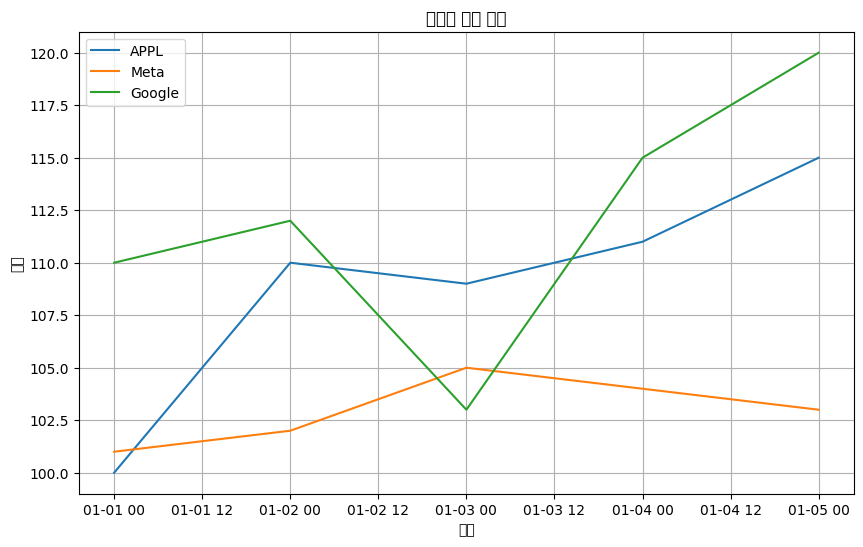

NameError: name 'plot' is not defined

In [10]:
exec(preprocessed)

In [10]:
preprocessed = "import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\nplt.show()\n\nchart = plot(data)"

In [11]:
pprint(preprocessed)

('import matplotlib.pyplot as plt\n'
 'import pandas as pd\n'
 '\n'
 "data = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', "
 "'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n"
 "        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', "
 "'2025-01-05'],\n"
 "        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, "
 '103, 115, 120]}\n'
 '\n'
 'df = pd.DataFrame(data)\n'
 "df['시간'] = pd.to_datetime(df['시간'])\n"
 '\n'
 'plt.figure(figsize=(10, 6))\n'
 "for name in df['이름'].unique():\n"
 "    subset = df[df['이름'] == name]\n"
 "    plt.plot(subset['시간'], subset['가격'], label=name)\n"
 '\n'
 "plt.xlabel('시간')\n"
 "plt.ylabel('가격')\n"
 "plt.title('시간에 따른 가격')\n"
 'plt.legend()\n'
 'plt.grid(True)\n'
 'plt.show()\n'
 '\n'
 'chart = plot(data)')


/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.

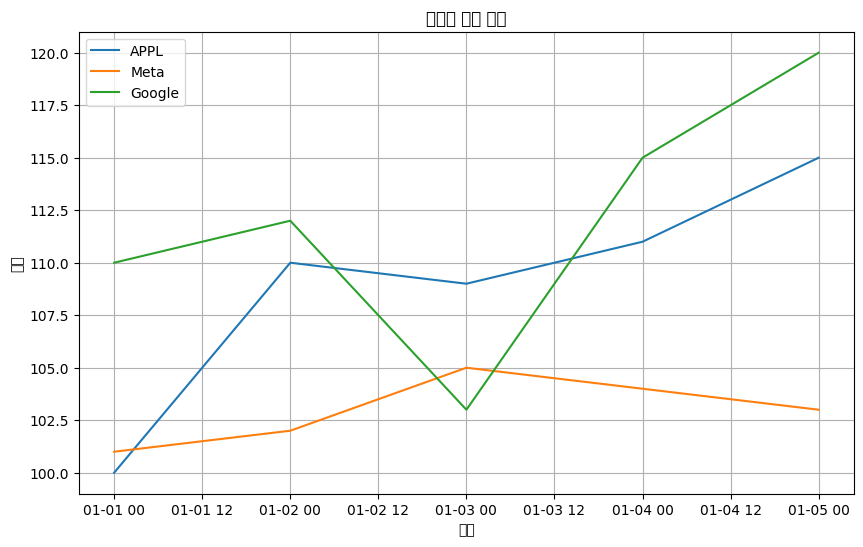

NameError: name 'plot' is not defined

In [12]:
exec(preprocessed)

## Encode Image to Base64


In [14]:
preprocessed = "import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\nplt.show()"

/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taehan/anaconda3/envs/multimodal/lib/python3.12/site-packages/IPython/core/pylabtools.

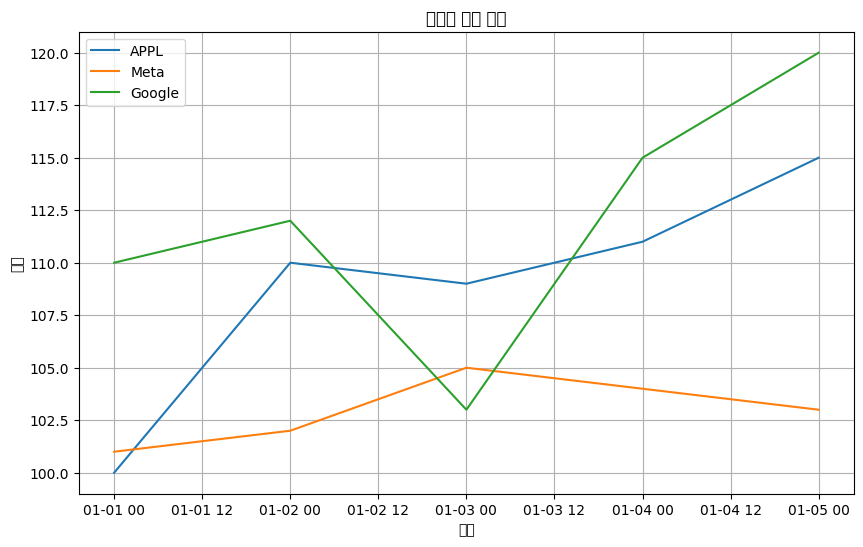


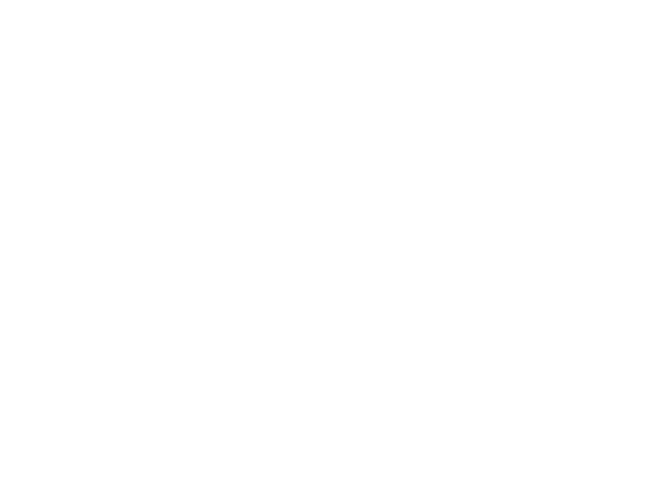

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import base64
import io

# First execute the code to generate the figure
exec(preprocessed)

# Capture the current figure to a bytes buffer
buffer = io.BytesIO()
plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
plt.close()  # Close the figure to free memory
buffer.seek(0)  # Move to the beginning of the buffer

# Encode the buffer to base64
img_str = base64.b64encode(buffer.getvalue()).decode('utf-8')

# Now img_str contains the base64 encoded image data
# You can save it to a file
with open("figure_image.b64", "w") as f:
    f.write(img_str)

# Or if you want to display it in a Jupyter notebook:
from IPython.display import HTML
HTML(f'<img src="data:image/png;base64,{img_str}">')

In [16]:
# Save as PNG file
with open("figure_image.png", "wb") as f:
    f.write(base64.b64decode(img_str))

## plt.show를 하지 않아야 하는 이유  

The key point is to make sure you save the figure before calling plt.show() or after recreating the figure, as plt.show() clears the current figure from memory.  

plt.show()는 현재의 figure를 메모리에서 지우기 때문에, plt.show()를 호출하기 전에 figure를 저장하거나, figure를 다시 생성한 후에 호출해야 한다.  

In [17]:
preprocessed = "import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\n"

/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_1962/1756381145.py:11: UserWarning: Glyph 


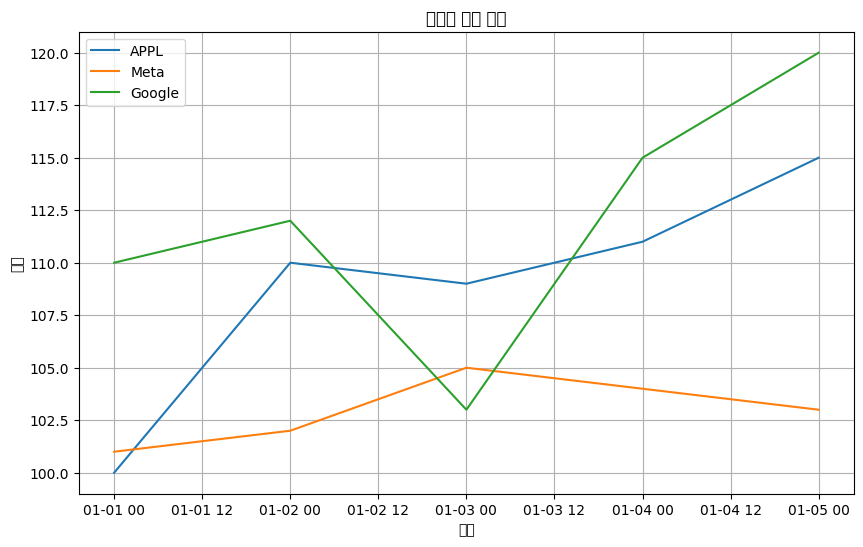

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import base64
import io

# First execute the code to generate the figure
exec(preprocessed)

# Capture the current figure to a bytes buffer
buffer = io.BytesIO()
plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
plt.close()  # Close the figure to free memory
buffer.seek(0)  # Move to the beginning of the buffer

# Encode the buffer to base64
img_str = base64.b64encode(buffer.getvalue()).decode('utf-8')

# Now img_str contains the base64 encoded image data
# You can save it to a file
with open("figure_image.b64", "w") as f:
    f.write(img_str)

# Or if you want to display it in a Jupyter notebook:
from IPython.display import HTML
HTML(f'<img src="data:image/png;base64,{img_str}">')

In [19]:
# Save as PNG file
with open("figure_image.png", "wb") as f:
    f.write(base64.b64decode(img_str))

## Matplotlib의 한글 문제 처리 in WSL    

References:  
https://velog.io/@redgreen/Linux-linux%EC%97%90%EC%84%9C-Matplotlib-%ED%95%9C%EA%B8%80%ED%8F%B0%ED%8A%B8-%EC%84%A4%EC%A0%95%ED%95%98%EA%B8%B0  
https://giveme-happyending.tistory.com/168  

In [3]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothicCoding')

In [4]:
preprocessed = "import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {'이름': ['APPL', 'APPL', 'APPL', 'APPL', 'APPL', 'Meta', 'Meta', 'Meta', 'Meta', 'Meta', 'Google', 'Google', 'Google', 'Google', 'Google'],\n        '시간': ['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05', '2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-05'],\n        '가격': [100, 110, 109, 111, 115, 101, 102, 105, 104, 103, 110, 112, 103, 115, 120]}\n\ndf = pd.DataFrame(data)\ndf['시간'] = pd.to_datetime(df['시간'])\n\nplt.figure(figsize=(10, 6))\nfor name in df['이름'].unique():\n    subset = df[df['이름'] == name]\n    plt.plot(subset['시간'], subset['가격'], label=name)\n\nplt.xlabel('시간')\nplt.ylabel('가격')\nplt.title('시간에 따른 가격')\nplt.legend()\nplt.grid(True)\n"


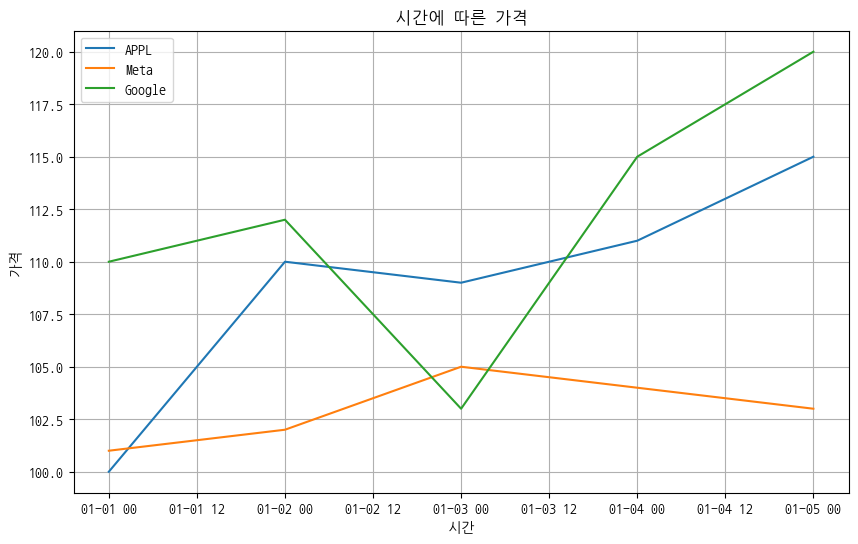

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import base64
import io

# First execute the code to generate the figure
exec(preprocessed)

# Capture the current figure to a bytes buffer
buffer = io.BytesIO()
plt.savefig(buffer, format='png', dpi=100, bbox_inches='tight')
plt.close()  # Close the figure to free memory
buffer.seek(0)  # Move to the beginning of the buffer

# Encode the buffer to base64
img_str = base64.b64encode(buffer.getvalue()).decode('utf-8')

# Now img_str contains the base64 encoded image data
# You can save it to a file
with open("figure_image.b64", "w") as f:
    f.write(img_str)

# Or if you want to display it in a Jupyter notebook:
from IPython.display import HTML
HTML(f'<img src="data:image/png;base64,{img_str}">')

## LIDA Prompt 참조  

In [ ]:
'''
# generating chart function  

def generate(self, summary: Dict, goal: Goal,
                 textgen_config: TextGenerationConfig, text_gen: TextGenerator, library='altair'):
        """Generate visualization code given a summary and a goal"""

        library_template, library_instructions = self.scaffold.get_template(goal, library)
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "system", "content": f"The dataset summary is : {summary} \n\n"},
            library_instructions,
            {"role": "user",
             "content":
             f"Always add a legend with various colors where appropriate. The visualization code MUST only use data fields that exist in the dataset (field_names) or fields that are transformations based on existing field_names). Only use variables that have been defined in the code or are in the dataset summary. You MUST return a FULL PYTHON PROGRAM ENCLOSED IN BACKTICKS ``` that starts with an import statement. DO NOT add any explanation. \n\n THE GENERATED CODE SOLUTION SHOULD BE CREATED BY MODIFYING THE SPECIFIED PARTS OF THE TEMPLATE BELOW \n\n {library_template} \n\n.The FINAL COMPLETED CODE BASED ON THE TEMPLATE above is ... \n\n"}]

        completions: TextGenerationResponse = text_gen.generate(
            messages=messages, config=textgen_config)
        response = [x['content'] for x in completions.text]

        
# get chart template function 

def get_template(self, goal: Goal, library: str):

        general_instructions = f"If the solution requires a single value (e.g. max, min, median, first, last etc), ALWAYS add a line (axvline or axhline) to the chart, ALWAYS with a legend containing the single value (formatted with 0.2F). If using a <field> where semantic_type=date, YOU MUST APPLY the following transform before using that column i) convert date fields to date types using data[''] = pd.to_datetime(data[<field>], errors='coerce'), ALWAYS use  errors='coerce' ii) drop the rows with NaT values data = data[pd.notna(data[<field>])] iii) convert field to right time format for plotting.  ALWAYS make sure the x-axis labels are legible (e.g., rotate when needed). Solve the task  carefully by completing ONLY the <imports> AND <stub> section. Given the dataset summary, the plot(data) method should generate a {library} chart ({goal.visualization}) that addresses this goal: {goal.question}. DO NOT WRITE ANY CODE TO LOAD THE DATA. The data is already loaded and available in the variable data."

        matplotlib_instructions = f" {general_instructions} DO NOT include plt.show(). The plot method must return a matplotlib object (plt). Think step by step. \n"

        if library == "matplotlib":
            instructions = {
                "role": "assistant",
                "content": f"  {matplotlib_instructions}. Use BaseMap for charts that require a map. "}
            template = \
                f"""
                import matplotlib.pyplot as plt
                import pandas as pd
                <imports>
                # plan -
                def plot(data: pd.DataFrame):
                    <stub> # only modify this section
                    plt.title('{goal.question}', wrap=True)
                    return plt;

                chart = plot(data) # data already contains the data to be plotted. Always include this line. No additional code beyond this line."""
'''

LIDA에서 작성한 프롬프트에서는 "DO NOT include plt.show()"라고 명시적으로 plt.show()를 배제한다.  
또한 def plot() 함수를 사용하고 plt 객체 자체를 반환한다.  
OpenAI의 API로 불러온 모델이 chart = plot(data)를 반환하는 이유가 벌써 LIDA와 관련된 사항을 많이 학습해서가 아닐가 하고 의심하게 된다.  